In [14]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [15]:
# 1. Import Libraries
# ==============================
import pandas as pd
import numpy as np
import random

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)
from keras.models import Model
from keras.optimizers import Adam
from tensorflow.keras.models import Sequential
from keras.layers import Input, Dense, Flatten, MultiHeadAttention, Dropout
import tensorflow as tf

In [16]:
# ==============================
# 2. Load Dataset
# ==============================
df = pd.read_csv('/content/drive/My Drive/Colab Notebooks/Research/Diabetes/diabetes_012_health_indicators_BRFSS2015.csv')

print("Dataset Shape:", df.shape)

Dataset Shape: (253680, 22)


In [17]:
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

In [18]:
# ==============================
# 3. Features & Target
# ==============================
X = df.drop(['Diabetes_012', 'AnyHealthcare'], axis=1)
y = df['Diabetes_012']

# ==============================
# 4. Train-Test Split
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [19]:
# ==============================
# 5. Feature Scaling
# ==============================
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(pd.Series(y_train).value_counts())

Diabetes_012
0.0    149592
2.0     24742
1.0      3242
Name: count, dtype: int64


In [20]:
# Step 1: ANN Input
ann_input = Input(shape=(X_train.shape[1],))

# Dense layers
x = Dense(32, activation='relu')(ann_input)

# Output
output_layer = Dense(3, activation='softmax')(x)

# Build model
model = Model(inputs=ann_input, outputs=output_layer)

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [21]:
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf

# Early stopping (monitor accuracy instead of loss)
early_stopping = EarlyStopping(
    monitor='accuracy',
    patience=10,
    restore_best_weights=True
)

# Start timing
start_time = tf.timestamp()

# Train model
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

# End timing
end_time = tf.timestamp()

# Convert to float
total_time = float(end_time - start_time)
average_time_per_epoch = total_time / len(history.history['loss'])

# Print results
print(f'Total Training Time: {total_time:.2f} seconds')
print(f'Average Time per Epoch: {average_time_per_epoch:.2f} seconds')

Epoch 1/20
5550/5550 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - accuracy: 0.8450 - loss: 0.4068
Epoch 2/20
5550/5550 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.8491 - loss: 0.3953
Epoch 3/20
5550/5550 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.8494 - loss: 0.3942
Epoch 4/20
5550/5550 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.8498 - loss: 0.3936
Epoch 5/20
5550/5550 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.8500 - loss: 0.3932
Epoch 6/20
5550/5550 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.8501 - loss: 0.3930
Epoch 7/20
5550/5550 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.8500 - loss: 0.3928
Epoch 8/20
5550/5550 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.8500 - loss: 0.3927
Epoch 9/20
5550/5550 ━━━━━━━━━━━━━━━━━━━━ 20s 3ms/step - accuracy: 0.8503 - loss: 0.3925
Epoch 10/20
5550/5550 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.8505 - loss: 0.3924
Epoch 11/20
5550/5550 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.8505 - loss: 0.3923
Epoch 12/20
5550/55

In [22]:
# ==============================
# 8. Evaluate Model
# ==============================
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)

print("\nTest Accuracy:", accuracy)


Test Accuracy: 0.8494822978973389


In [23]:
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score

In [24]:
# ==============================
# 8. Prediction
# ==============================
y_prob = model.predict(X_test)
y_pred = np.argmax(y_prob, axis=1)

2379/2379 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step


In [25]:
# ==============================
# 9. Metrics
# ==============================
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Weighted Metrics
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"\nWeighted Precision: {precision:.4f}")
print(f"Weighted Recall: {recall:.4f}")
print(f"Weighted F1-Score: {f1:.4f}")


Confusion Matrix:
[[63067     0  1044]
 [ 1289     0   100]
 [ 9022     0  1582]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.86      0.98      0.92     64111
         1.0       0.00      0.00      0.00      1389
         2.0       0.58      0.15      0.24     10604

    accuracy                           0.85     76104
   macro avg       0.48      0.38      0.38     76104
weighted avg       0.80      0.85      0.81     76104


Weighted Precision: 0.8049
Weighted Recall: 0.8495
Weighted F1-Score: 0.8059


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

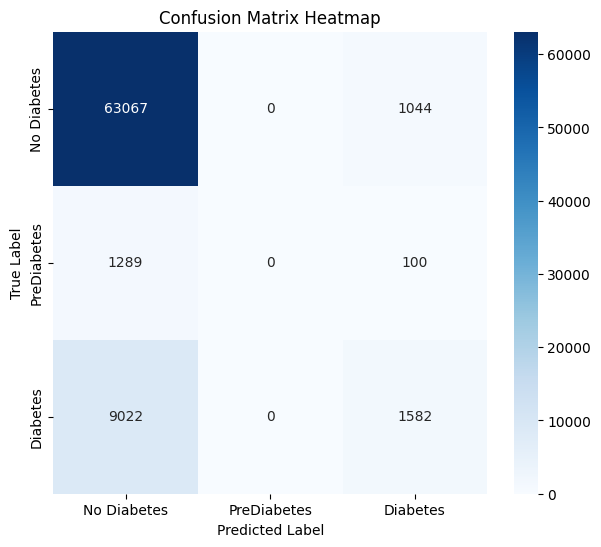

In [26]:
# ==============================
# 10. Confusion Matrix Visualization
# ==============================
import matplotlib.pyplot as plt
import seaborn as sns

classes = ['No Diabetes', 'PreDiabetes', 'Diabetes']

plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=classes,
    yticklabels=classes
)

plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()